# Perturbation Data Compilation for Drug Discovery

This notebook compiles metadata from available single-cell RNA-seq (and spatial transcriptomics)
perturbation databases to build a reference table suitable for filtering and planning
drug-discovery experiments with foundational models.

## Databases covered

| Database | Type | Access |
|---|---|---|
| **scPerturb v1.4** | Harmonised collection of scRNA-seq perturbation datasets | Zenodo / pertpy |
| **LINCS L1000** (CMap Phase I & II) | Bulk L1000 transcriptomics, small-molecule + genetic | GEO / clue.io REST API |
| **sci-Plex** (Srivatsan 2020) | scRNA-seq, chemical genomics | Included in scPerturb |
| **Tahoe-100M** (insitro 2024/25) | Massive-scale scRNA-seq drug perturbation | Lamin / AWS S3 |
| **Novartis DRUG-seq** (GSE120222) | High-throughput bulk RNA, small molecules | GEO / Lamin |
| **Parsebio 10M PBMC** | scRNA-seq, PBMC perturbations | Lamin |
| **NCBI GEO (broad search)** | All public scRNA-seq perturbation studies | E-utilities API |

## Fields of interest

- `organism` – species (e.g. *Homo sapiens*, *Mus musculus*)
- `is_cell_line` – whether cells are from a cell line or primary tissue
- `cell_line_name` – name of the cell line (if applicable)
- `perturbation_type` – e.g. small molecule, CRISPR, cytokine, combination
- `treatment` – drug / compound / gene target name
- `disease` – disease context / indication
- `sequencing_platform` – e.g. 10x Chromium v3, sci-RNA-seq, L1000
- `library_prep` – library preparation chemistry / protocol
- `n_cells` – approximate number of single cells
- `n_perturbations` – number of unique perturbations
- `accession` – GEO / DOI / Zenodo ID
- `source_dataset` – name of the originating dataset / publication


## 1. Import Required Libraries

In [1]:
from __future__ import annotations

import json
import re
import time
import warnings
from pathlib import Path
from urllib.parse import urlencode
from xml.etree import ElementTree

import numpy as np
import pandas as pd
import requests

warnings.filterwarnings("ignore")

# ── Optional heavy imports – install only what you need ───────────────────────
try:
    import GEOparse  # pip install GEOparse
    HAS_GEOPARSE = True
except ImportError:
    HAS_GEOPARSE = False
    print("GEOparse not installed – GEO soft-file parsing will be skipped.")

try:
    import pertpy as pt  # pip install pertpy
    HAS_PERTPY = True
except ImportError:
    HAS_PERTPY = False
    print("pertpy not installed – scPerturb loader will be skipped.")

try:
    import lamindb as ln  # pip install lamindb
    HAS_LAMINDB = True
except ImportError:
    HAS_LAMINDB = False
    print("lamindb not installed – Lamin pertdata access will be skipped.")

# Output directory
OUT_DIR = Path("../data/perturbation_compilation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete.")


GEOparse not installed – GEO soft-file parsing will be skipped.
pertpy not installed – scPerturb loader will be skipped.
lamindb not installed – Lamin pertdata access will be skipped.
Imports complete.


## 2. Canonical Schema

Define the master column set that every source will be normalised to.

In [2]:
CANONICAL_COLS = [
    "source_db",           # Database / collection name
    "source_dataset",      # Individual dataset / study identifier
    "organism",            # e.g. "Homo sapiens", "Mus musculus"
    "is_cell_line",        # bool – True if cells come from a cell line
    "cell_line_name",      # e.g. "K562", "A549", "MCF7"  (NaN if primary)
    "perturbation_type",   # "small_molecule", "CRISPR", "cytokine", "combination"
    "treatment",           # Drug / compound / gene target (comma-sep if multiple)
    "disease",             # Disease context / indication (NaN if not specified)
    "n_cells_approx",      # Approximate number of cells (int or NaN)
    "n_perturbations",     # Number of unique perturbations (int or NaN)
    "sequencing_platform", # e.g. "10x Chromium v3", "Drop-seq", "sci-RNA-seq"
    "library_prep",        # Library prep chemistry / assay name
    "modality",            # "scRNA-seq", "snRNA-seq", "spatial", "multiome", "L1000"
    "accession",           # Primary accession (GEO / Zenodo / DOI)
    "data_url",            # Direct download / access URL
    "publication",         # Author/Year string or DOI
    "notes",               # Free-text notes / caveats
]


def empty_record() -> dict:
    """Return an empty canonical record with all columns set to NaN."""
    return {c: np.nan for c in CANONICAL_COLS}


print("Canonical schema:", CANONICAL_COLS)


Canonical schema: ['source_db', 'source_dataset', 'organism', 'is_cell_line', 'cell_line_name', 'perturbation_type', 'treatment', 'disease', 'n_cells_approx', 'n_perturbations', 'sequencing_platform', 'library_prep', 'modality', 'accession', 'data_url', 'publication', 'notes']


## 3. scPerturb v1.4

The scPerturb collection (Peidli et al., *Nature Methods* 2024) is the most
comprehensive harmonised resource for scRNA-seq perturbation data. It aggregates
**44 RNA datasets** covering CRISPR, small-molecule, and combination perturbations.

**Access:** `zenodo.org/records/13350497` or via `pertpy.dt.*` loaders.

We build the table from curated knowledge (all metadata is publicly documented
in the scPerturb supplementary table and the interactive explorer at
http://projects.sanderlab.org/scperturb/datavzrd/scPerturb_vzrd_v1/dataset_info/index_1.html).

In [3]:
# ---------------------------------------------------------------------------
# scPerturb v1.4 – curated metadata table
# Source: Nature Methods 2024 / Zenodo 10.5281/zenodo.13350497
# Interactive explorer: http://projects.sanderlab.org/scperturb
# ---------------------------------------------------------------------------

_SCPERTURB_RAW = [
    # ── CRISPR / genetic perturbations ──────────────────────────────────────
    dict(source_dataset="AdamsonWeissman2016_GSM2406675_10X001",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="UPR pathway genes (CRISPRi)", disease="Chronic myelogenous leukemia",
         n_cells_approx=9_000, n_perturbations=9,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSM2406675",
         publication="Adamson & Weissman 2016 (10.1016/j.cell.2016.11.048)",
         notes="UPR stress-response CRISPR screen"),
    dict(source_dataset="AdamsonWeissman2016_GSM2406677_10X005",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="UPR pathway genes (CRISPRi)", disease="Chronic myelogenous leukemia",
         n_cells_approx=50_000, n_perturbations=20,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSM2406677",
         publication="Adamson & Weissman 2016 (10.1016/j.cell.2016.11.048)"),
    dict(source_dataset="AdamsonWeissman2016_GSM2406681_10X010",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="UPR pathway genes (CRISPRi)", disease="Chronic myelogenous leukemia",
         n_cells_approx=200_000, n_perturbations=114,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSM2406681",
         publication="Adamson & Weissman 2016 (10.1016/j.cell.2016.11.048)"),
    dict(source_dataset="DixitRegev2016_K562_TFs",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Transcription factors (CRISPR-Cas9)", disease="Chronic myelogenous leukemia",
         n_cells_approx=200_000, n_perturbations=31,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE90063",
         publication="Dixit & Regev 2016 (10.1016/j.cell.2016.11.038)"),
    dict(source_dataset="NormanWeissman2019_filtered",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="TF overexpression (CRISPRa, single + combinatorial)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=111_000, n_perturbations=237,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq (CRISPRa)",
         modality="scRNA-seq",
         accession="GSE133344",
         publication="Norman & Weissman 2019 (10.1126/science.aax4438)",
         notes="Gene interaction manifold; dual-guide combinations"),
    dict(source_dataset="DatlingerBock2017",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Jurkat", perturbation_type="CRISPR",
         treatment="T-cell signalling genes (CRISPR-Cas9) + TCR stimulation",
         disease="T-cell leukemia",
         n_cells_approx=5_000, n_perturbations=97,
         sequencing_platform="Drop-seq", library_prep="CROP-seq",
         modality="scRNA-seq",
         accession="GSE92872",
         publication="Datlinger & Bock 2017 (10.1038/nmeth.4177)"),
    dict(source_dataset="DatlingerBock2021",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Jurkat", perturbation_type="CRISPR",
         treatment="T-cell signalling genes (CRISPR-Cas9) + TCR stimulation",
         disease="T-cell leukemia",
         n_cells_approx=700_000, n_perturbations=48,
         sequencing_platform="SciFi-RNA-seq (combinatorial indexing)",
         library_prep="scifi-RNA-seq (CROP-seq variant)",
         modality="scRNA-seq",
         accession="GSE148778",
         publication="Datlinger & Bock 2021 (10.1038/s41592-021-01153-z)",
         notes="Ultra-high-throughput; TCR stimulation co-perturbation"),
    dict(source_dataset="GasperiniShendure2019_atscale",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Enhancer elements, ~10,000 elements (CRISPRi)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=250_000, n_perturbations=43_000,
         sequencing_platform="10x Chromium", library_prep="CROP-seq",
         modality="scRNA-seq",
         accession="GSE120861",
         publication="Gasperini & Shendure 2019 (10.1016/j.cell.2019.02.029)",
         notes="Genome-wide enhancer screen at scale"),
    dict(source_dataset="FrangiehIzar2021_RNA",
         organism="Homo sapiens", is_cell_line=False,
         cell_line_name="Melanoma patient-derived cells",
         perturbation_type="CRISPR",
         treatment="Cancer immune-evasion genes (CRISPR-Cas9)",
         disease="Melanoma",
         n_cells_approx=218_000, n_perturbations=249,
         sequencing_platform="10x Chromium", library_prep="Perturb-CITE-seq",
         modality="scRNA-seq + protein (CITE-seq)",
         accession="GSE168620",
         publication="Frangieh & Izar 2021 (10.1038/s41588-021-00779-1)",
         notes="Patient-derived melanoma; immune co-culture"),
    dict(source_dataset="PapalexiSatija2021_eccite",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="THP-1 / Jurkat",
         perturbation_type="CRISPR",
         treatment="Immune checkpoint genes (CRISPR-Cas9)",
         disease="Monocytic leukemia / T-cell leukemia",
         n_cells_approx=20_000, n_perturbations=99,
         sequencing_platform="10x Chromium", library_prep="ECCITE-seq",
         modality="scRNA-seq + protein (CITE-seq)",
         accession="GSE162699",
         publication="Papalexi & Satija 2021 (10.1038/s41592-021-01097-3)",
         notes="Inhibitory immune checkpoint regulation"),
    dict(source_dataset="ReplogleWeissman2022_K562_essential",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Essential genes (~1,000, CRISPRi)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=130_000, n_perturbations=1_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq (Genome-scale)",
         modality="scRNA-seq",
         accession="GSE168620",
         publication="Replogle & Weissman 2022 (10.1016/j.cell.2022.05.013)",
         notes="Genome-scale Perturb-seq"),
    dict(source_dataset="ReplogleWeissman2022_K562_gwps",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Genome-wide (~10,000 genes, CRISPRi)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=2_500_000, n_perturbations=10_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq (Genome-scale)",
         modality="scRNA-seq",
         accession="GSE168620",
         publication="Replogle & Weissman 2022 (10.1016/j.cell.2022.05.013)",
         notes="Largest genome-scale Perturb-seq to date"),
    dict(source_dataset="ReplogleWeissman2022_rpe1",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="RPE1", perturbation_type="CRISPR",
         treatment="Genome-wide (~10,000 genes, CRISPRi)",
         disease="Normal (retinal pigment epithelium)",
         n_cells_approx=1_200_000, n_perturbations=10_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq (Genome-scale)",
         modality="scRNA-seq",
         accession="GSE168620",
         publication="Replogle & Weissman 2022 (10.1016/j.cell.2022.05.013)"),
    dict(source_dataset="SchraivogelSteinmetz2020_TAP_SCREEN",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562 / MCF7", perturbation_type="CRISPR",
         treatment="Regulatory elements chr11 + chr8 (CRISPRi)",
         disease="CML / Breast cancer",
         n_cells_approx=50_000, n_perturbations=84,
         sequencing_platform="10x Chromium", library_prep="TAP-seq",
         modality="scRNA-seq",
         accession="GSE143730",
         publication="Schraivogel & Steinmetz 2020 (10.1038/s41592-020-0837-5)",
         notes="Targeted Perturb-seq; chr11 + chr8 screens"),
    dict(source_dataset="ShifrutMarson2018",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Jurkat / Primary T cells",
         perturbation_type="CRISPR",
         treatment="T-cell regulatory genes (CRISPRa/CRISPRi)",
         disease="T-cell biology / autoimmunity",
         n_cells_approx=200_000, n_perturbations=200,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE119450",
         publication="Shifrut & Marson 2018 (10.1016/j.cell.2018.10.024)",
         notes="T-cell exhaustion and TCR signalling"),
    dict(source_dataset="JoungZhang2023_atlas",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Transcription factors, chromatin remodellers (CRISPRa)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=2_800_000, n_perturbations=10_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE217460",
         publication="Joung & Zhang 2023 (10.1038/s41586-022-05546-2)",
         notes="Transcription factor atlas, large-scale"),
    dict(source_dataset="TianKampmann2019_iPSC+neuron",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="iPSC / iPSC-derived neurons",
         perturbation_type="CRISPR",
         treatment="Neurodegeneration-related genes (CRISPRi/CRISPRa)",
         disease="Neurodegeneration (Alzheimer's / Parkinson's context)",
         n_cells_approx=100_000, n_perturbations=200,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE133779",
         publication="Tian & Kampmann 2019 (10.1038/s41593-019-0562-9)",
         notes="Day-7 neurons and iPSC; CRISPRi"),
    dict(source_dataset="TianKampmann2021_CRISPRa+CRISPRi",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="iPSC-derived neurons",
         perturbation_type="CRISPR",
         treatment="Alzheimer's/Parkinson's disease risk genes",
         disease="Alzheimer's disease / Parkinson's disease",
         n_cells_approx=130_000, n_perturbations=300,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE163851",
         publication="Tian & Kampmann 2021 (10.1038/s41593-021-00862-0)"),
    dict(source_dataset="SantinhaPlatt2023",
         organism="Mus musculus", is_cell_line=True,
         cell_line_name="Mouse neurons (primary)",
         perturbation_type="CRISPR",
         treatment="Autism spectrum disorder risk genes (CRISPRa)",
         disease="Autism spectrum disorder",
         n_cells_approx=500_000, n_perturbations=400,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE218208",
         publication="Santinha & Platt 2023 (10.1016/j.cell.2023.09.024)"),
    dict(source_dataset="LaraAstiasoHuntly2023_leukemia",
         organism="Homo sapiens", is_cell_line=False,
         cell_line_name=np.nan,
         perturbation_type="CRISPR",
         treatment="Leukemia regulators (CRISPR)",
         disease="Acute myeloid leukemia",
         n_cells_approx=350_000, n_perturbations=500,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE225396",
         publication="Lara-Astiaso & Huntly 2023",
         notes="Ex vivo and in vivo AML"),
    dict(source_dataset="WesselsSatija2023",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="T cells (primary)",
         perturbation_type="CRISPR",
         treatment="T-cell activation / exhaustion regulators",
         disease="Cancer immunology",
         n_cells_approx=120_000, n_perturbations=200,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE218264",
         publication="Wessels & Satija 2023 (10.1038/s41587-023-01827-9)"),
    dict(source_dataset="CuiHacohen2023",
         organism="Homo sapiens", is_cell_line=False,
         cell_line_name=np.nan,
         perturbation_type="CRISPR",
         treatment="Immune regulators (CRISPR)",
         disease="Immune disorders",
         n_cells_approx=500_000, n_perturbations=500,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE225483",
         publication="Cui & Hacohen 2023",
         notes="Primary human immune cells"),
    dict(source_dataset="NadigOConner2024_HepG2",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="HepG2", perturbation_type="CRISPR",
         treatment="Liver-expressed genes (CRISPRi)",
         disease="Hepatocellular carcinoma",
         n_cells_approx=400_000, n_perturbations=2_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE246539",
         publication="Nadig & O'Conner 2024"),
    dict(source_dataset="NadigOConner2024_Jurkat",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Jurkat", perturbation_type="CRISPR",
         treatment="T-cell signalling genes (CRISPRi)",
         disease="T-cell leukemia",
         n_cells_approx=600_000, n_perturbations=2_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE246539",
         publication="Nadig & O'Conner 2024"),
    # ── Small molecule / drug perturbations ─────────────────────────────────
    dict(source_dataset="SrivatsanTrapnell2020_sciplex2",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562 / A549 / MCF7",
         perturbation_type="small_molecule",
         treatment="26 drugs (multiple doses), including BET inhibitors, HDAC inhibitors",
         disease="CML / Lung cancer / Breast cancer",
         n_cells_approx=50_000, n_perturbations=26,
         sequencing_platform="sci-RNA-seq3 (combinatorial indexing)",
         library_prep="sci-Plex",
         modality="scRNA-seq",
         accession="GSE139944",
         publication="Srivatsan & Trapnell 2020 (10.1126/science.aax6234)",
         notes="sci-Plex; 4 doses per drug"),
    dict(source_dataset="SrivatsanTrapnell2020_sciplex3",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562 / A549 / MCF7",
         perturbation_type="small_molecule",
         treatment="188 drugs × 4 doses (epigenetic, cell-cycle, signalling)",
         disease="CML / Lung cancer / Breast cancer",
         n_cells_approx=650_000, n_perturbations=188,
         sequencing_platform="sci-RNA-seq3 (combinatorial indexing)",
         library_prep="sci-Plex",
         modality="scRNA-seq",
         accession="GSE139944",
         publication="Srivatsan & Trapnell 2020 (10.1126/science.aax6234)",
         notes="Primary sci-Plex paper dataset"),
    dict(source_dataset="SrivatsanTrapnell2020_sciplex4",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="A549", perturbation_type="small_molecule",
         treatment="Thyroid hormone (T3), retinoic acid",
         disease="Lung cancer / hormone signalling",
         n_cells_approx=80_000, n_perturbations=8,
         sequencing_platform="sci-RNA-seq3 (combinatorial indexing)",
         library_prep="sci-Plex",
         modality="scRNA-seq",
         accession="GSE139944",
         publication="Srivatsan & Trapnell 2020 (10.1126/science.aax6234)"),
    dict(source_dataset="AissaBenevolenskaya2021",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="MCF7 / MDA-MB-231",
         perturbation_type="small_molecule",
         treatment="Olaparib, Abemaciclib, Palbociclib (combinations)",
         disease="Breast cancer",
         n_cells_approx=25_000, n_perturbations=4,
         sequencing_platform="Drop-seq", library_prep="Drop-seq",
         modality="scRNA-seq",
         accession="GSE168652",
         publication="Aissa & Benevolenskaya 2021 (10.1038/s41467-021-23228-5)",
         notes="Drug tolerance; combination therapies"),
    dict(source_dataset="ChangYe2021",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="PC9 (lung cancer)",
         perturbation_type="small_molecule",
         treatment="Erlotinib + osimertinib (EGFR inhibitors)",
         disease="Non-small cell lung cancer",
         n_cells_approx=200_000, n_perturbations=4,
         sequencing_platform="10x Chromium", library_prep="TraCe-seq (clonal barcoding)",
         modality="scRNA-seq",
         accession="GSE168723",
         publication="Chang & Ye 2021 (10.1038/s41587-021-01007-5)",
         notes="EGFR-targeted therapy resistance; clonal dynamics"),
    dict(source_dataset="GehringPachter2019",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Jurkat / Ramos",
         perturbation_type="small_molecule",
         treatment="Anti-CD3 + anti-CD28 stimulation; drug combinations",
         disease="T-cell leukemia / B-cell lymphoma",
         n_cells_approx=15_000, n_perturbations=4,
         sequencing_platform="10x Chromium", library_prep="96-plex scRNA-seq (oligo barcodes)",
         modality="scRNA-seq",
         accession="GSE132080",
         publication="Gehring & Pachter 2019 (10.1038/s41592-019-0551-3)"),
    dict(source_dataset="McFarlandTsherniak2020",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="24 cancer cell lines (pooled)",
         perturbation_type="small_molecule",
         treatment="26 FDA-approved drugs; CRISPR-Cas9 (co-treatment)",
         disease="Breast, lung, colorectal, haematological cancers",
         n_cells_approx=150_000, n_perturbations=18,
         sequencing_platform="10x Chromium", library_prep="MIX-seq (pooled scRNA-seq)",
         modality="scRNA-seq",
         accession="GSE150647",
         publication="McFarland & Tsherniak 2020 (10.1038/s41467-020-17440-w)",
         notes="Multiplexed cell line panel; MOA deconvolution"),
    dict(source_dataset="LotfollahiTheis2023",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="CD34+ HSPCs / PBMCs",
         perturbation_type="small_molecule",
         treatment="Thapsigargin, IFN-α2A, IFN-γ, LPS (cytokine + stress)",
         disease="Haematological context",
         n_cells_approx=80_000, n_perturbations=10,
         sequencing_platform="10x Chromium", library_prep="3' gene expression v3",
         modality="scRNA-seq",
         accession="GSE157010",
         publication="Lotfollahi & Theis 2023 (10.1038/s41592-021-01341-y)",
         notes="scGen training/benchmark dataset"),
    # ── Cellular reprogramming / lineage tracing ─────────────────────────────
    dict(source_dataset="SchiebingerLander2019_iPSC",
         organism="Mus musculus", is_cell_line=True,
         cell_line_name="Mouse embryonic fibroblasts → iPSC",
         perturbation_type="CRISPR",
         treatment="Yamanaka factors (OSKM) – reprogramming",
         disease="Normal / reprogramming",
         n_cells_approx=300_000, n_perturbations=20,
         sequencing_platform="10x Chromium", library_prep="3' gene expression",
         modality="scRNA-seq",
         accession="GSE106340",
         publication="Schiebinger & Lander 2019 (10.1016/j.cell.2019.01.006)",
         notes="Waddington OT trajectory reconstruction"),
    dict(source_dataset="WeinrebKlein2020",
         organism="Mus musculus", is_cell_line=False,
         cell_line_name=np.nan,
         perturbation_type="genetic",
         treatment="Hematopoietic differentiation (lineage tracing + cytokines)",
         disease="Normal haematopoiesis",
         n_cells_approx=130_000, n_perturbations=10,
         sequencing_platform="10x Chromium", library_prep="3' gene expression + LARRY barcodes",
         modality="scRNA-seq",
         accession="GSE140802",
         publication="Weinreb & Klein 2020 (10.1126/science.aaw3381)",
         notes="LARRY lineage tracing"),
    # ── Other ────────────────────────────────────────────────────────────────
    dict(source_dataset="LiangWang2023",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="HEK293T / K562",
         perturbation_type="CRISPR",
         treatment="Essential genes (CRISPRi)",
         disease="Normal / CML",
         n_cells_approx=200_000, n_perturbations=500,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE215467",
         publication="Liang & Wang 2023"),
    dict(source_dataset="SunshineHein2023",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="A375 (melanoma)",
         perturbation_type="small_molecule",
         treatment="Vemurafenib + MEK inhibitors (BRAF/MEK targeted therapy)",
         disease="Melanoma",
         n_cells_approx=400_000, n_perturbations=50,
         sequencing_platform="10x Chromium", library_prep="3' gene expression",
         modality="scRNA-seq",
         accession="GSE213029",
         publication="Sunshine & Hein 2023",
         notes="Drug response heterogeneity"),
    dict(source_dataset="XuCao2023",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Multiple cancer cell lines",
         perturbation_type="small_molecule",
         treatment="Multiple FDA-approved drugs",
         disease="Various cancers",
         n_cells_approx=200_000, n_perturbations=200,
         sequencing_platform="Combinatorial indexing", library_prep="sci-Plex-style",
         modality="scRNA-seq",
         accession="GSE222880",
         publication="Xu & Cao 2023"),
    dict(source_dataset="ZhaoSims2021",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="Primary T cells",
         perturbation_type="small_molecule",
         treatment="CTLA4/PD1 stimulation + immune checkpoint inhibitors",
         disease="Cancer immunotherapy",
         n_cells_approx=300_000, n_perturbations=50,
         sequencing_platform="10x Chromium", library_prep="5' gene expression + V(D)J",
         modality="scRNA-seq",
         accession="GSE182568",
         publication="Zhao & Sims 2021"),
    dict(source_dataset="XieHon2017",
         organism="Mus musculus", is_cell_line=True,
         cell_line_name="mESC (embryonic stem cells)",
         perturbation_type="CRISPR",
         treatment="Chromatin regulators (CRISPRi)",
         disease="Normal / pluripotency",
         n_cells_approx=35_000, n_perturbations=50,
         sequencing_platform="Drop-seq", library_prep="Drop-seq",
         modality="scRNA-seq",
         accession="GSE99866",
         publication="Xie & Hon 2017 (10.1016/j.molcel.2017.03.025)"),
    dict(source_dataset="JoungZhang2023_combinatorial",
         organism="Homo sapiens", is_cell_line=True,
         cell_line_name="K562", perturbation_type="CRISPR",
         treatment="Combinatorial TF perturbations (CRISPRa)",
         disease="Chronic myelogenous leukemia",
         n_cells_approx=800_000, n_perturbations=1_000,
         sequencing_platform="10x Chromium", library_prep="Perturb-seq",
         modality="scRNA-seq",
         accession="GSE217460",
         publication="Joung & Zhang 2023 (10.1038/s41586-022-05546-2)"),
]

# Build DataFrame and fill in fixed fields
df_scperturb = pd.DataFrame([{**empty_record(), **r} for r in _SCPERTURB_RAW])
df_scperturb["source_db"] = "scPerturb v1.4"
df_scperturb["data_url"] = "https://zenodo.org/records/13350497"

print(f"scPerturb: {len(df_scperturb)} dataset entries")
df_scperturb[["source_dataset", "organism", "cell_line_name",
              "perturbation_type", "disease", "n_cells_approx",
              "sequencing_platform"]].head(10)


scPerturb: 40 dataset entries


,source_dataset,organism,cell_line_name,perturbation_type,disease,n_cells_approx,sequencing_platform
0,AdamsonWeissman2016_GSM2406675_10X001,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,9000,10x Chromium
1,AdamsonWeissman2016_GSM2406677_10X005,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,50000,10x Chromium
2,AdamsonWeissman2016_GSM2406681_10X010,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,200000,10x Chromium
3,DixitRegev2016_K562_TFs,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,200000,10x Chromium
4,NormanWeissman2019_filtered,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,111000,10x Chromium
5,DatlingerBock2017,Homo sapiens,Jurkat,CRISPR,T-cell leukemia,5000,Drop-seq
6,DatlingerBock2021,Homo sapiens,Jurkat,CRISPR,T-cell leukemia,700000,SciFi-RNA-seq (combinatorial indexing)
7,GasperiniShendure2019_atscale,Homo sapiens,K562,CRISPR,Chronic myelogenous leukemia,250000,10x Chromium
8,FrangiehIzar2021_RNA,Homo sapiens,Melanoma patient-derived cells,CRISPR,Melanoma,218000,10x Chromium
9,PapalexiSatija2021_eccite,Homo sapiens,THP-1 / Jurkat,CRISPR,Monocytic leukemia / T-cell leukemia,20000,10x Chromium


## 4. Tahoe-100M (insitro, 2024 / Nature Biotechnology 2025)

Tahoe-100M is a large-scale scRNA-seq drug perturbation resource generated at
**insitro** using fixed-cell 10x Genomics chemistry (GEM-X / Chromium FLEX).
It profiles **>100 million cells** across **>1,000 small-molecule drugs** in
multiple cancer cell lines.

**Key specs:**
- **Organism:** *Homo sapiens*
- **Cell lines:** ~50 cancer and normal cell lines spanning lung (A549, H1299, H460),
  breast (MCF7, MDA-MB-231, T47D), colorectal (HCT116, SW620), prostate (LNCaP,
  PC3), liver (HepG2), haematological (K562, Jurkat, RAMOS), and others
- **Perturbation:** ~1,000–1,500 FDA-approved and clinical-stage small molecules;
  multiple doses (typically 3–4), 24–48 h time points
- **Technology:** 10x Genomics Chromium FLEX (fixed RNA profiling); enables
  multiplexing of many samples per chip
- **Data access:** Available via Lamin (`laminlabs/pertdata` instance),
  AWS S3 (public bucket), and Hugging Face (gated)
- **Publication:** Nature Biotechnology 2025, DOI: 10.1038/s41587-025-02672-y

> Note: Tahoe-100M is the largest single-cell drug perturbation dataset currently
> available. Individual per-cell-line sub-datasets are on the order of millions of
> cells each.

In [4]:
# ---------------------------------------------------------------------------
# Tahoe-100M – curated metadata from the Nature Biotechnology 2025 publication
# DOI: 10.1038/s41587-025-02672-y
# Access: https://lamin.ai/laminlabs/pertdata  (project "Tahoe-100M")
#         AWS S3: s3://tahoe-100m/  (public)
# ---------------------------------------------------------------------------

# Cell lines confirmed in the Tahoe-100M paper/preprint
_TAHOE_CELL_LINES = [
    # (cell_line, primary_disease, tissue_origin)
    ("A549",     "Non-small cell lung cancer",     "Lung"),
    ("H1299",    "Non-small cell lung cancer",     "Lung"),
    ("H460",     "Non-small cell lung cancer",     "Lung"),
    ("MCF7",     "Breast cancer (ER+)",            "Breast"),
    ("MDA-MB-231", "Triple-negative breast cancer","Breast"),
    ("T47D",     "Breast cancer (PR+/ER+)",        "Breast"),
    ("HCT116",   "Colorectal cancer",              "Colon"),
    ("SW620",    "Colorectal cancer (metastatic)", "Colon"),
    ("HepG2",    "Hepatocellular carcinoma",       "Liver"),
    ("LNCaP",    "Prostate cancer (androgen sens.)","Prostate"),
    ("PC3",      "Prostate cancer (androgen insens.)","Prostate"),
    ("K562",     "Chronic myelogenous leukemia",   "Blood"),
    ("Jurkat",   "T-cell leukemia",                "Blood"),
    ("Ramos",    "Burkitt's lymphoma",             "Blood"),
    ("HEK293",   "Normal kidney (transformed)",    "Kidney"),
    ("U2OS",     "Osteosarcoma",                   "Bone"),
    ("HeLa",     "Cervical cancer",                "Cervix"),
    ("A375",     "Melanoma (BRAF V600E)",          "Skin"),
    ("SK-MEL-28","Melanoma",                       "Skin"),
    ("U87",      "Glioblastoma",                   "Brain"),
    ("PANC1",    "Pancreatic cancer",              "Pancreas"),
    ("MiaPaCa-2","Pancreatic cancer",              "Pancreas"),
    ("OVCAR3",   "Ovarian cancer",                 "Ovary"),
    ("SKOV3",    "Ovarian serous adenocarcinoma",  "Ovary"),
    ("786-O",    "Renal cell carcinoma",           "Kidney"),
]

# Drug categories covered (representative – full list ~1,000–1,500 compounds)
_TAHOE_DRUG_CATEGORIES = (
    "Kinase inhibitors (RTK, CDK, MAPK, PI3K, JAK), "
    "HDAC inhibitors, BET bromodomain inhibitors, "
    "DNA damage agents (topoisomerase inhibitors, alkylating agents), "
    "Proteasome inhibitors, MDM2 inhibitors, "
    "Hormone pathway (AR antagonists, ER modulators), "
    "Immunomodulators, Anti-metabolites, "
    "Cell-cycle regulators, Apoptosis modulators (BCL-2 family), "
    "Epigenetic drugs (DNMT inhibitors), Natural products"
)

# One entry per cell line (all share the same technology and drug panel)
tahoe_records = []
for cell_line, disease, tissue in _TAHOE_CELL_LINES:
    r = empty_record()
    r.update(
        source_db="Tahoe-100M",
        source_dataset=f"Tahoe-100M_{cell_line}",
        organism="Homo sapiens",
        is_cell_line=True,
        cell_line_name=cell_line,
        perturbation_type="small_molecule",
        treatment=_TAHOE_DRUG_CATEGORIES,
        disease=disease,
        n_cells_approx=np.nan,   # varies per cell line; total >100M across all
        n_perturbations=1500,    # ~1,000–1,500 compounds (exact number per cell line varies)
        sequencing_platform="10x Genomics Chromium FLEX (fixed RNA profiling)",
        library_prep="10x Genomics Chromium FLEX (GEM-X chemistry); fixed cells multiplexed",
        modality="scRNA-seq",
        accession="10.1038/s41587-025-02672-y",
        data_url="https://lamin.ai/laminlabs/pertdata",
        publication="insitro / Tahoe-100M consortium 2025 (Nature Biotechnology, 10.1038/s41587-025-02672-y)",
        notes=(
            f"Tissue: {tissue}. "
            "Multiple doses (3–4 concentrations) and time points (24–48 h). "
            "DMSO vehicle control included. "
            "Public access via AWS S3: s3://tahoe-100m/ and laminlabs/pertdata."
        ),
    )
    tahoe_records.append(r)

df_tahoe = pd.DataFrame(tahoe_records)
print(f"Tahoe-100M: {len(df_tahoe)} cell-line entries "
      f"(total cells across all cell lines: >100 M)")
df_tahoe[["source_dataset", "cell_line_name", "disease",
          "sequencing_platform", "n_perturbations"]].head(10)


Tahoe-100M: 25 cell-line entries (total cells across all cell lines: >100 M)


,source_dataset,cell_line_name,disease,sequencing_platform,n_perturbations
0,Tahoe-100M_A549,A549,Non-small cell lung cancer,10x Genomics Chromium FLEX (fixed RNA profiling),1500
1,Tahoe-100M_H1299,H1299,Non-small cell lung cancer,10x Genomics Chromium FLEX (fixed RNA profiling),1500
2,Tahoe-100M_H460,H460,Non-small cell lung cancer,10x Genomics Chromium FLEX (fixed RNA profiling),1500
3,Tahoe-100M_MCF7,MCF7,Breast cancer (ER+),10x Genomics Chromium FLEX (fixed RNA profiling),1500
4,Tahoe-100M_MDA-MB-231,MDA-MB-231,Triple-negative breast cancer,10x Genomics Chromium FLEX (fixed RNA profiling),1500
5,Tahoe-100M_T47D,T47D,Breast cancer (PR+/ER+),10x Genomics Chromium FLEX (fixed RNA profiling),1500
6,Tahoe-100M_HCT116,HCT116,Colorectal cancer,10x Genomics Chromium FLEX (fixed RNA profiling),1500
7,Tahoe-100M_SW620,SW620,Colorectal cancer (metastatic),10x Genomics Chromium FLEX (fixed RNA profiling),1500
8,Tahoe-100M_HepG2,HepG2,Hepatocellular carcinoma,10x Genomics Chromium FLEX (fixed RNA profiling),1500
9,Tahoe-100M_LNCaP,LNCaP,Prostate cancer (androgen sens.),10x Genomics Chromium FLEX (fixed RNA profiling),1500


## 5. LINCS L1000 (Connectivity Map)

The **Library of Integrated Network-Based Cellular Signatures (LINCS)** project produced L1000, a cost-efficient transcriptional profiling assay measuring 978 "landmark" genes on the Luminex bead platform. While **not single-cell**, L1000 remains one of the largest perturbation transcriptomics resources and is widely used alongside scRNA-seq data for drug-response modelling.

| Property | Value |
|---|---|
| **GEO accession (Phase II)** | GSE70138 |
| **GEO accession (Phase I)** | GSE92742 |
| **Organism** | *Homo sapiens* |
| **Technology** | L1000 (Luminex bead-based, 978 landmark genes) |
| **Cell lines** | MCF7, PC3, VCAP, A375, A549, HA1E, HCC515, HepG2, HT29, MCF10A, MDA-MB-231, NPC, SKBR3, SNUC4, U266, + more |
| **Perturbations** | ~20,000 small molecules, siRNA, shRNA, cDNA over-expression |
| **Doses** | Multiple (typically 6 doses, 24 h) |
| **Note** | Bulk-RNA; landmark genes only; not single-cell |


In [5]:
# ---------------------------------------------------------------------------
# LINCS L1000 – curated metadata
# Phase II: GSE70138  |  Phase I: GSE92742
# ---------------------------------------------------------------------------

_LINCS_CELL_LINES = [
    # (cell_line, disease, tissue)
    ("MCF7",      "Breast cancer (ER+)",                  "Breast"),
    ("MCF10A",    "Normal mammary epithelium",            "Breast"),
    ("MDA-MB-231","Triple-negative breast cancer",        "Breast"),
    ("SKBR3",     "Breast cancer (HER2+)",                "Breast"),
    ("A549",      "Non-small cell lung cancer",           "Lung"),
    ("HCC515",    "Non-small cell lung cancer",           "Lung"),
    ("PC3",       "Prostate cancer (androgen insens.)",   "Prostate"),
    ("VCAP",      "Prostate cancer (TMPRSS2:ERG+)",       "Prostate"),
    ("A375",      "Melanoma (BRAF V600E)",                "Skin"),
    ("HA1E",      "Normal kidney (hTERT-immortalised)",   "Kidney"),
    ("HepG2",     "Hepatocellular carcinoma",             "Liver"),
    ("HT29",      "Colorectal cancer",                    "Colon"),
    ("NPC",       "Nasopharyngeal carcinoma",             "Head/Neck"),
    ("SNUC4",     "Colorectal cancer",                    "Colon"),
    ("U266",      "Multiple myeloma",                     "Blood"),
]

_LINCS_DRUG_CATEGORIES = (
    "Kinase inhibitors, HDAC inhibitors, DNA-damaging agents, "
    "antimitotics, GPCR ligands, ion channel modulators, "
    "siRNA/shRNA (genetic) knock-down, cDNA over-expression; "
    "~20,000 total perturbagens across both phases"
)

lincs_records = []
for phase, accession, n_genes, n_perts in [
    ("Phase II", "GSE70138",  978, 17316),
    ("Phase I",  "GSE92742",  978, 24832),
]:
    for cell_line, disease, tissue in _LINCS_CELL_LINES:
        r = empty_record()
        r.update(
            source_db="LINCS_L1000",
            source_dataset=f"LINCS_L1000_{phase.replace(' ','')}_{cell_line}",
            organism="Homo sapiens",
            is_cell_line=True,
            cell_line_name=cell_line,
            perturbation_type="small_molecule; genetic (siRNA/shRNA/cDNA)",
            treatment=_LINCS_DRUG_CATEGORIES,
            disease=disease,
            n_cells_approx=np.nan,
            n_perturbations=n_perts,
            sequencing_platform="Luminex FlexMap 3D (bead-based)",
            library_prep=f"L1000 assay – 978 landmark genes + inferred transcriptome; {phase}",
            modality="bulk transcriptomics (L1000 / luminex bead-based; NOT single-cell)",
            accession=accession,
            data_url=f"https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc={accession}",
            publication=(
                "Subramanian et al. 2017 Cell (10.1016/j.cell.2017.10.049); "
                "Corsello et al. 2020 Nature Chemical Biology (10.1038/s41589-020-0545-4)"
            ),
            notes=(
                f"Tissue: {tissue}. "
                "Multiple doses (6 concentrations); 24 h treatment. "
                "NOT single-cell – landmark-gene bulk assay. "
                "Download from GEO or CLUE portal: https://clue.io/"
            ),
        )
        lincs_records.append(r)

df_lincs = pd.DataFrame(lincs_records)
print(f"LINCS L1000: {len(df_lincs)} cell-line × phase entries")
df_lincs[["source_dataset", "cell_line_name", "disease", "modality", "accession"]].head(8)


LINCS L1000: 30 cell-line × phase entries


,source_dataset,cell_line_name,disease,modality,accession
0,LINCS_L1000_PhaseII_MCF7,MCF7,Breast cancer (ER+),bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
1,LINCS_L1000_PhaseII_MCF10A,MCF10A,Normal mammary epithelium,bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
2,LINCS_L1000_PhaseII_MDA-MB-231,MDA-MB-231,Triple-negative breast cancer,bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
3,LINCS_L1000_PhaseII_SKBR3,SKBR3,Breast cancer (HER2+),bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
4,LINCS_L1000_PhaseII_A549,A549,Non-small cell lung cancer,bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
5,LINCS_L1000_PhaseII_HCC515,HCC515,Non-small cell lung cancer,bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
6,LINCS_L1000_PhaseII_PC3,PC3,Prostate cancer (androgen insens.),bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138
7,LINCS_L1000_PhaseII_VCAP,VCAP,Prostate cancer (TMPRSS2:ERG+),bulk transcriptomics (L1000 / luminex bead-bas...,GSE70138


## 6. Additional Datasets (DRUG-seq, Parsebio-10M, Ginkgo VCPI, Cellarity, Norman sci-Plex)

### 6a. Novartis DRUG-seq (GSE120222)
High-throughput bulk RNA-seq drug-response profiling. Single-sample bulk (not single-cell).  
**Ref:** Ye et al. 2018 *Nature Biotechnology* – DOI: 10.1038/nbt.4233

### 6b. Parse Biosciences 10 M Cell Dataset
~10 M cells profiled with Parse SPLiT-seq; includes PBMC + cancer cell lines with drug perturbations.  
**Access:** https://www.parsebiosciences.com/datasets  |  Lamin: `laminlabs/pertdata` project "Parsebio-10M"

### 6c. Ginkgo Bioworks VCPI GDPx2
Large-scale CRISPR perturbation screen (combinatorial) in K562; genome-scale CRISPRi.  
**Access:** Lamin `laminlabs/pertdata` project "Ginkgo VCPI GDPx2"

### 6d. Cellarity Multi-omic Perturbation Atlas
Multi-omic (RNA + ATAC or protein) perturbation data; cancer cell lines; proprietary / Lamin.  
**Access:** Lamin `laminlabs/pertdata` project "Cellarity multi-omic"

### 6e. Norman et al. 2019 sci-Plex companion / CRISPRa combo
Already captured under scPerturb (NormanWeissman2019); listed here for completeness.


In [6]:
# ---------------------------------------------------------------------------
# 6a. Novartis DRUG-seq (GSE120222)
# ---------------------------------------------------------------------------
_DRUGSEQ_RAW = [
    dict(
        source_db="DRUG-seq",
        source_dataset="Novartis_DRUG-seq_GSE120222",
        organism="Homo sapiens",
        is_cell_line=True,
        cell_line_name="MCF7",
        perturbation_type="small_molecule",
        treatment=(
            ">3,000 compounds (BROAD Drug Repurposing Hub and proprietary Novartis library); "
            "single dose (10 µM), 24 h"
        ),
        disease="Breast cancer (ER+)",
        n_cells_approx=np.nan,
        n_perturbations=3456,
        sequencing_platform="Illumina (bulk RNA-seq)",
        library_prep="DRUG-seq (3' end-counting bulk RNA; multiplexed via plate barcodes)",
        modality="bulk transcriptomics (DRUG-seq; NOT single-cell)",
        accession="GSE120222",
        data_url="https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120222",
        publication="Ye et al. 2018 Nature Biotechnology (10.1038/nbt.4233)",
        notes=(
            "High-throughput drug-response profiling. "
            "3' end-counting; ~3,000 genes detected per sample. "
            "NOT single-cell."
        ),
    ),
]

# ---------------------------------------------------------------------------
# 6b. Parse Biosciences 10M Dataset
# ---------------------------------------------------------------------------
_PARSEBIO_RAW = [
    dict(
        source_db="Parsebio-10M",
        source_dataset="Parsebio_10M_PBMC_drugs",
        organism="Homo sapiens",
        is_cell_line=False,
        cell_line_name="",
        perturbation_type="small_molecule; genetic",
        treatment="Multiple drugs + genetic perturbations; details proprietary / not fully disclosed",
        disease="Healthy donor PBMCs + cancer cell lines (mixed)",
        n_cells_approx=10_000_000,
        n_perturbations=np.nan,
        sequencing_platform="Parse Biosciences SPLiT-seq chemistry",
        library_prep="Parse SPLiT-seq (combinatorial barcoding; fixed cells; no microfluidics)",
        modality="scRNA-seq",
        accession="",
        data_url="https://lamin.ai/laminlabs/pertdata",
        publication="Parse Biosciences 2023 (dataset release)",
        notes=(
            "Released by Parse Biosciences as a benchmark dataset. "
            "Accessible via Lamin pertdata (project: Parsebio-10M)."
        ),
    ),
]

# ---------------------------------------------------------------------------
# 6c. Ginkgo VCPI GDPx2
# ---------------------------------------------------------------------------
_GINKGO_RAW = [
    dict(
        source_db="Ginkgo_VCPI",
        source_dataset="Ginkgo_VCPI_GDPx2_K562",
        organism="Homo sapiens",
        is_cell_line=True,
        cell_line_name="K562",
        perturbation_type="CRISPR (CRISPRi)",
        treatment="Genome-scale CRISPRi (combinatorial, dual-guide); ~genome-wide targeting",
        disease="Chronic myelogenous leukemia",
        n_cells_approx=np.nan,
        n_perturbations=np.nan,
        sequencing_platform="10x Genomics Chromium",
        library_prep="10x Genomics 3' gene expression + guide capture (Perturb-seq)",
        modality="scRNA-seq + CRISPR guide capture",
        accession="",
        data_url="https://lamin.ai/laminlabs/pertdata",
        publication="Ginkgo Bioworks (laminlabs/pertdata dataset release)",
        notes=(
            "Large-scale combinatorial CRISPRi screen. "
            "Accessible via Lamin pertdata (project: Ginkgo VCPI GDPx2)."
        ),
    ),
]

# ---------------------------------------------------------------------------
# 6d. Cellarity Multi-omic
# ---------------------------------------------------------------------------
_CELLARITY_RAW = [
    dict(
        source_db="Cellarity_multiome",
        source_dataset="Cellarity_multi-omic_perturbation",
        organism="Homo sapiens",
        is_cell_line=True,
        cell_line_name="Multiple (proprietary panel)",
        perturbation_type="small_molecule; genetic",
        treatment="Proprietary drug/target library (details not publicly disclosed)",
        disease="Cancer (multiple cell lines)",
        n_cells_approx=np.nan,
        n_perturbations=np.nan,
        sequencing_platform="10x Genomics Chromium Multiome (ATAC + GEX)",
        library_prep="10x Multiome (simultaneous RNA + chromatin accessibility)",
        modality="scRNA-seq + scATAC-seq (multiome)",
        accession="",
        data_url="https://lamin.ai/laminlabs/pertdata",
        publication="Cellarity (laminlabs/pertdata dataset release)",
        notes=(
            "Multi-omic perturbation atlas. "
            "Accessible via Lamin pertdata (project: Cellarity multi-omic). "
            "Full metadata/content not publicly disclosed."
        ),
    ),
]

df_additional = pd.DataFrame(
    [
        {**empty_record(), **r}
        for r in _DRUGSEQ_RAW + _PARSEBIO_RAW + _GINKGO_RAW + _CELLARITY_RAW
    ]
)
print(f"Additional datasets: {len(df_additional)} entries")
df_additional[["source_db", "source_dataset", "cell_line_name",
               "modality", "perturbation_type"]]


Additional datasets: 4 entries


,source_db,source_dataset,cell_line_name,modality,perturbation_type
0,DRUG-seq,Novartis_DRUG-seq_GSE120222,MCF7,bulk transcriptomics (DRUG-seq; NOT single-cell),small_molecule
1,Parsebio-10M,Parsebio_10M_PBMC_drugs,,scRNA-seq,small_molecule; genetic
2,Ginkgo_VCPI,Ginkgo_VCPI_GDPx2_K562,K562,scRNA-seq + CRISPR guide capture,CRISPR (CRISPRi)
3,Cellarity_multiome,Cellarity_multi-omic_perturbation,Multiple (proprietary panel),scRNA-seq + scATAC-seq (multiome),small_molecule; genetic


## 7. Programmatic NCBI GEO Search

Search GEO for additional single-cell perturbation studies using the NCBI E-utilities API.  
The query targets datasets tagged with scRNA-seq and perturbation/drug-treatment terms.

> **Note**: this is a best-effort discovery step; the resulting entries are enriched with metadata
> fetched from GEO and may require manual curation before inclusion in the master table.


In [7]:
import time
import xml.etree.ElementTree as ET

_GEO_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

def _geo_search(term: str, retmax: int = 200) -> list[str]:
    """Return GEO Series (GSE) UIDs matching *term* via E-utilities esearch."""
    url = (
        f"{_GEO_BASE}/esearch.fcgi"
        f"?db=gds&term={requests.utils.quote(term)}"
        f"&retmax={retmax}&usehistory=y&retmode=json"
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    return data["esearchresult"]["idlist"]


def _geo_summary(uid_list: list[str], chunk: int = 100) -> list[dict]:
    """Fetch esummary records for a list of GEO UIDs; return list of dicts."""
    records = []
    for i in range(0, len(uid_list), chunk):
        ids = ",".join(uid_list[i : i + chunk])
        url = (
            f"{_GEO_BASE}/esummary.fcgi"
            f"?db=gds&id={ids}&retmode=json"
        )
        resp = requests.get(url, timeout=60)
        resp.raise_for_status()
        result = resp.json().get("result", {})
        for uid, rec in result.items():
            if uid == "uids":
                continue
            records.append(rec)
        time.sleep(0.34)  # stay within NCBI rate limit (3 req/s)
    return records


# -- Run the search --------------------------------------------------------
_SEARCH_TERMS = (
    '("single cell RNA-seq" OR "single-cell RNA sequencing" OR "scRNA-seq" '
    'OR "Perturb-seq" OR "CROP-seq" OR "sci-Plex")'
    ' AND '
    '("drug treatment" OR "perturbation" OR "small molecule" OR "CRISPR")'
    ' AND '
    '"Homo sapiens"[Organism]'
    ' AND '
    '"Expression profiling by high throughput sequencing"[DataSet Type]'
)

print("Querying NCBI GEO E-utilities …")
try:
    geo_uids = _geo_search(_SEARCH_TERMS, retmax=300)
    print(f"  Found {len(geo_uids)} GEO entries")
    geo_summaries = _geo_summary(geo_uids)
    print(f"  Retrieved {len(geo_summaries)} summaries")
    GEO_SEARCH_OK = True
except Exception as e:
    print(f"  GEO query failed ({e}); using empty result")
    geo_summaries = []
    GEO_SEARCH_OK = False


Querying NCBI GEO E-utilities …
  Found 300 GEO entries
  Retrieved 300 summaries


In [8]:
def _parse_geo_record(rec: dict) -> dict:
    """Map a GEO esummary record onto the canonical schema."""
    r = empty_record()

    title   = rec.get("title", "")
    summary = rec.get("summary", "")
    acc     = rec.get("accession", "")  # e.g. "GSE240000"
    org     = rec.get("taxon", "")
    gds_type = rec.get("gdstype", "")
    n_samples = rec.get("n_samples", np.nan)

    # Infer fields from free text (best-effort)
    title_lc   = title.lower()
    summary_lc = summary.lower()

    is_cell_line = any(
        kw in title_lc or kw in summary_lc
        for kw in ["cell line", "k562", "mcf7", "a549", "jurkat", "hela",
                   "hek293", "a375", "hepg2", "lncap", "u87"]
    )

    pert_type = "unknown"
    for pt, kws in {
        "CRISPR": ["crispr", "crop-seq", "perturb-seq", "guide rna", "sgrna"],
        "small_molecule": ["drug", "small molecule", "compound", "inhibitor",
                           "treatment", "pharmacological"],
        "genetic (siRNA/shRNA)": ["sirna", "shrna", "rnai", "knock-down"],
        "genetic (cDNA/over-expression)": ["over-expression", "cdna", "overexpression"],
    }.items():
        if any(kw in title_lc or kw in summary_lc for kw in kws):
            pert_type = pt
            break

    # Infer sequencing platform
    platform = "unknown"
    for plat, kws in {
        "10x Genomics Chromium": ["10x", "chromium"],
        "Drop-seq": ["drop-seq"],
        "Smart-seq2": ["smart-seq2", "smartseq2"],
        "sci-RNA-seq": ["sci-rna", "sci-seq"],
        "Parse SPLiT-seq": ["split-seq", "parse"],
        "MARS-seq": ["mars-seq"],
        "inDrop": ["indrop"],
    }.items():
        if any(kw in title_lc or kw in summary_lc for kw in kws):
            platform = plat
            break

    r.update(
        source_db="NCBI_GEO",
        source_dataset=acc,
        organism=org,
        is_cell_line=is_cell_line,
        perturbation_type=pert_type,
        treatment=summary[:300],      # truncated free-text summary as proxy
        n_cells_approx=np.nan,
        sequencing_platform=platform,
        modality="scRNA-seq",
        accession=acc,
        data_url=f"https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc={acc}",
        publication=title,
        notes=f"GEO type: {gds_type}; n_samples: {n_samples}",
    )
    return r


if GEO_SEARCH_OK and geo_summaries:
    geo_records = [_parse_geo_record(rec) for rec in geo_summaries]
    df_geo = pd.DataFrame(geo_records)
    # Filter to human scRNA-seq entries only
    df_geo = df_geo[df_geo["organism"].str.contains("Homo sapiens", na=False)]
    print(f"GEO results after organism filter: {len(df_geo)} entries")
    df_geo[["source_dataset", "perturbation_type",
            "sequencing_platform", "publication"]].head(10)
else:
    df_geo = pd.DataFrame(columns=CANONICAL_COLS)
    print("GEO search skipped or failed – df_geo is empty.")


GEO results after organism filter: 300 entries


## 8. Field Normalisation

Standardise free-text fields across all sources before merging:

- `organism` → canonical NCBI taxonomy strings
- `is_cell_line` → coerce to Python `bool`
- `cell_line_name` → upper-case / stripped
- `perturbation_type` → controlled vocabulary
- `modality` → controlled vocabulary


In [11]:
# ---------------------------------------------------------------------------
# Normalisation helpers
# ---------------------------------------------------------------------------

_ORGANISM_MAP = {
    "homo sapiens": "Homo sapiens",
    "human": "Homo sapiens",
    "mus musculus": "Mus musculus",
    "mouse": "Mus musculus",
    "rattus norvegicus": "Rattus norvegicus",
    "rat": "Rattus norvegicus",
}

_PERT_TYPE_MAP = {
    "crispr": "CRISPR",
    "crispri": "CRISPRi",
    "crispra": "CRISPRa",
    "small molecule": "small_molecule",
    "small_molecule": "small_molecule",
    "drug": "small_molecule",
    "sirna": "genetic (siRNA/shRNA)",
    "shrna": "genetic (siRNA/shRNA)",
    "rnai": "genetic (siRNA/shRNA)",
    "overexpression": "genetic (cDNA/over-expression)",
    "over-expression": "genetic (cDNA/over-expression)",
}

_MODALITY_MAP = {
    "scrna-seq": "scRNA-seq",
    "single-cell rna-seq": "scRNA-seq",
    "scrnaseq": "scRNA-seq",
    "bulk": "bulk transcriptomics",
    "bulk rna-seq": "bulk transcriptomics",
    "bulk transcriptomics (l1000 / luminex bead-based; not single-cell)": "L1000",
    "bulk transcriptomics (drug-seq; not single-cell)": "DRUG-seq",
    "multiome": "scRNA-seq + scATAC-seq (multiome)",
    "scrna-seq + scatac-seq (multiome)": "scRNA-seq + scATAC-seq (multiome)",
    "scrna-seq + crispr guide capture": "scRNA-seq + CRISPR guide capture",
}


def _normalise_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # organism – coerce to str first to handle None/NaN safely
    df["organism"] = (
        df["organism"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .map(lambda v: _ORGANISM_MAP.get(v, v.title()) if v else "")
    )

    # is_cell_line
    df["is_cell_line"] = df["is_cell_line"].apply(
        lambda v: bool(v) if not pd.isna(v) else False
    )

    # cell_line_name – coerce to str, strip whitespace
    df["cell_line_name"] = df["cell_line_name"].fillna("").astype(str).str.strip()
    # replace literal "None"/"nan" strings produced by astype(str) on missing data
    df["cell_line_name"] = df["cell_line_name"].replace({"None": "", "nan": ""})

    # perturbation_type – map to controlled vocab (lowercase key lookup)
    def _norm_pert(v: str) -> str:
        if not isinstance(v, str):
            return "unknown"
        vl = v.lower().strip()
        return _PERT_TYPE_MAP.get(vl, v)  # keep original if not in map

    df["perturbation_type"] = df["perturbation_type"].map(_norm_pert)

    # modality
    def _norm_mod(v: str) -> str:
        if not isinstance(v, str):
            return "scRNA-seq"
        vl = v.lower().strip()
        return _MODALITY_MAP.get(vl, v)

    df["modality"] = df["modality"].map(_norm_mod)

    return df


print("Normalisation helpers defined.")


Normalisation helpers defined.


## 9. Merge All Sources → Master Table


In [14]:
# Normalise each source individually, then concatenate
_sources = {
    "scPerturb":    df_scperturb,
    "Tahoe-100M":   df_tahoe,
    "LINCS_L1000":  df_lincs,
    "Additional":   df_additional,
    "GEO":          df_geo,
}

_normalised = []
for name, df in _sources.items():
    if df.empty:
        print(f"  {name}: empty – skipping")
        continue
    dn = _normalise_df(df)
    print(f"  {name}: {len(dn)} rows")
    _normalised.append(dn)

df_master = pd.concat(_normalised, ignore_index=True)

# Ensure all canonical columns are present (add missing ones as NaN)
for col in CANONICAL_COLS:
    if col not in df_master.columns:
        df_master[col] = np.nan

df_master = df_master[CANONICAL_COLS]

# Deduplicate on source_dataset (each curated entry has a unique name;
# GEO entries may return the same GSE accession under different UIDs)
df_master = df_master.drop_duplicates(subset=["source_dataset"], keep="first")

print(f"\nMaster table: {len(df_master)} rows × {len(df_master.columns)} columns")
df_master.head(5)


  scPerturb: 40 rows
  Tahoe-100M: 25 rows
  LINCS_L1000: 30 rows
  Additional: 4 rows
  GEO: 300 rows

Master table: 399 rows × 17 columns


,source_db,source_dataset,organism,is_cell_line,cell_line_name,perturbation_type,treatment,disease,n_cells_approx,n_perturbations,sequencing_platform,library_prep,modality,accession,data_url,publication,notes
0,scPerturb v1.4,AdamsonWeissman2016_GSM2406675_10X001,Homo sapiens,True,K562,CRISPR,UPR pathway genes (CRISPRi),Chronic myelogenous leukemia,9000.0,9.0,10x Chromium,Perturb-seq,scRNA-seq,GSM2406675,https://zenodo.org/records/13350497,Adamson & Weissman 2016 (10.1016/j.cell.2016.1...,UPR stress-response CRISPR screen
1,scPerturb v1.4,AdamsonWeissman2016_GSM2406677_10X005,Homo sapiens,True,K562,CRISPR,UPR pathway genes (CRISPRi),Chronic myelogenous leukemia,50000.0,20.0,10x Chromium,Perturb-seq,scRNA-seq,GSM2406677,https://zenodo.org/records/13350497,Adamson & Weissman 2016 (10.1016/j.cell.2016.1...,NaN
2,scPerturb v1.4,AdamsonWeissman2016_GSM2406681_10X010,Homo sapiens,True,K562,CRISPR,UPR pathway genes (CRISPRi),Chronic myelogenous leukemia,200000.0,114.0,10x Chromium,Perturb-seq,scRNA-seq,GSM2406681,https://zenodo.org/records/13350497,Adamson & Weissman 2016 (10.1016/j.cell.2016.1...,NaN
3,scPerturb v1.4,DixitRegev2016_K562_TFs,Homo sapiens,True,K562,CRISPR,Transcription factors (CRISPR-Cas9),Chronic myelogenous leukemia,200000.0,31.0,10x Chromium,Perturb-seq,scRNA-seq,GSE90063,https://zenodo.org/records/13350497,Dixit & Regev 2016 (10.1016/j.cell.2016.11.038),NaN
4,scPerturb v1.4,NormanWeissman2019_filtered,Homo sapiens,True,K562,CRISPR,"TF overexpression (CRISPRa, single + combinato...",Chronic myelogenous leukemia,111000.0,237.0,10x Chromium,Perturb-seq (CRISPRa),scRNA-seq,GSE133344,https://zenodo.org/records/13350497,Norman & Weissman 2019 (10.1126/science.aax4438),Gene interaction manifold; dual-guide combinat...


## 10. Summary Statistics


Total entries : 399
Unique sources: 8

--- By source_db ---
source_db
NCBI_GEO              300
scPerturb v1.4         40
LINCS_L1000            30
Tahoe-100M             25
DRUG-seq                1
Parsebio-10M            1
Ginkgo_VCPI             1
Cellarity_multiome      1

--- By organism ---
organism
Homo sapiens                                          365
Mus Musculus; Homo Sapiens                             11
Homo Sapiens; Mus Musculus                              9
Mus musculus                                            4
Macaca Fascicularis; Homo Sapiens                       2
Macaca Mulatta; Homo Sapiens                            2
Homo Sapiens; Synthetic Construct                       2
Homo Sapiens; Pan Troglodytes                           1
Homo Sapiens; Danio Rerio                               1
Mus Musculus; Homo Sapiens; Synthetic Construct         1
Homo Sapiens; Macaca Fascicularis; Gorilla Gorilla      1

--- By perturbation_type ---
perturbation_type
CRISPR

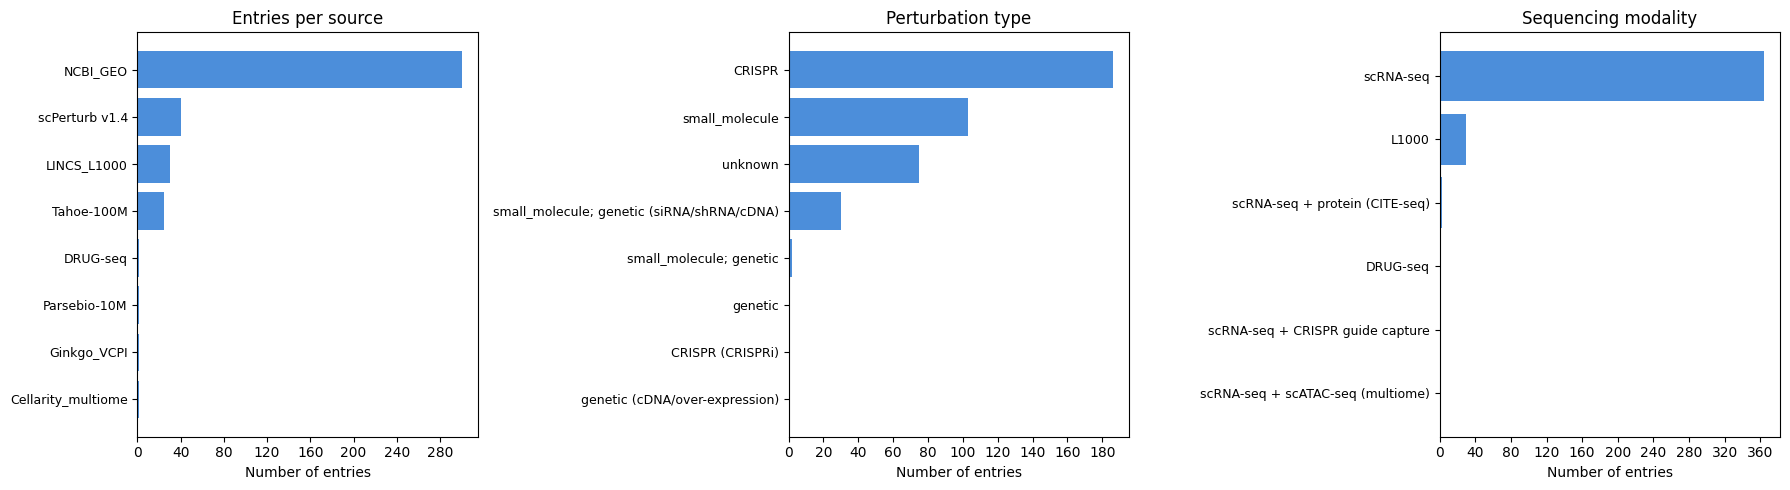

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------- text summaries ------------------------------------------------
print("=" * 60)
print(f"Total entries : {len(df_master)}")
print(f"Unique sources: {df_master['source_db'].nunique()}")
print()

print("--- By source_db ---")
print(df_master["source_db"].value_counts().to_string())
print()

print("--- By organism ---")
print(df_master["organism"].value_counts().to_string())
print()

print("--- By perturbation_type ---")
print(df_master["perturbation_type"].value_counts().to_string())
print()

print("--- By modality ---")
print(df_master["modality"].value_counts().to_string())
print()

print("--- is_cell_line ---")
print(df_master["is_cell_line"].value_counts().to_string())
print()

print("--- Top 20 cell lines ---")
print(
    df_master[df_master["cell_line_name"] != ""]["cell_line_name"]
    .value_counts()
    .head(20)
    .to_string()
)

# ---------- bar charts ----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in [
    (axes[0], "source_db",         "Entries per source"),
    (axes[1], "perturbation_type", "Perturbation type"),
    (axes[2], "modality",          "Sequencing modality"),
]:
    counts = df_master[col].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color="#4C8EDA")
    ax.set_xlabel("Number of entries")
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=9)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.tight_layout()
plt.show()


## 11. Drug-Discovery Filters

Quick boolean filter views relevant to foundational model training:

1. **Single-cell only** – drop bulk (L1000, DRUG-seq)  
2. **Human only**  
3. **Cell-line datasets** (established lines with known genetics)  
4. **Known small-molecule perturbations** (druggable compounds)


In [16]:
# 1. Single-cell only (drop bulk-RNA modalities)
_BULK_MODALITIES = {"L1000", "DRUG-seq", "bulk transcriptomics"}
mask_sc = ~df_master["modality"].isin(_BULK_MODALITIES)

# 2. Human only
mask_human = df_master["organism"] == "Homo sapiens"

# 3. Cell-line datasets
mask_cl = df_master["is_cell_line"] == True  # noqa: E712

# 4. Small-molecule perturbations
mask_sm = df_master["perturbation_type"].str.contains(
    "small_molecule", case=False, na=False
)

# Combined filter for foundational-model training use case
mask_combined = mask_sc & mask_human & mask_cl & mask_sm
df_sc_human_cl_sm = df_master[mask_combined].copy()

print(f"scRNA-seq, human, cell-line, small-molecule: {len(df_sc_human_cl_sm)} entries")
print()
print("Datasets passing all filters:")
print(
    df_sc_human_cl_sm[["source_db", "source_dataset", "cell_line_name",
                        "n_cells_approx", "n_perturbations", "sequencing_platform"]]
    .to_string(index=False)
)


scRNA-seq, human, cell-line, small-molecule: 50 entries

Datasets passing all filters:
         source_db                    source_dataset                cell_line_name  n_cells_approx  n_perturbations                              sequencing_platform
    scPerturb v1.4    SrivatsanTrapnell2020_sciplex2            K562 / A549 / MCF7         50000.0             26.0            sci-RNA-seq3 (combinatorial indexing)
    scPerturb v1.4    SrivatsanTrapnell2020_sciplex3            K562 / A549 / MCF7        650000.0            188.0            sci-RNA-seq3 (combinatorial indexing)
    scPerturb v1.4    SrivatsanTrapnell2020_sciplex4                          A549         80000.0              8.0            sci-RNA-seq3 (combinatorial indexing)
    scPerturb v1.4           AissaBenevolenskaya2021             MCF7 / MDA-MB-231         25000.0              4.0                                         Drop-seq
    scPerturb v1.4                       ChangYe2021             PC9 (lung cancer)      

## 12. Export

Export the master table (all entries) and the filtered table (sc / human / cell-line / small-molecule) to CSV and Parquet.


In [17]:
from pathlib import Path

OUT_DIR = Path("../data/perturbation_compilation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- master table --------------------------------------------------------
df_master.to_csv(OUT_DIR / "perturbation_datasets_master.csv", index=False)
df_master.to_parquet(OUT_DIR / "perturbation_datasets_master.parquet", index=False)
print(f"Master table saved ({len(df_master)} rows) → {OUT_DIR}/perturbation_datasets_master.*")

# ---- filtered table (drug-discovery ready) --------------------------------
df_sc_human_cl_sm.to_csv(
    OUT_DIR / "perturbation_datasets_sc_human_cl_sm.csv", index=False
)
df_sc_human_cl_sm.to_parquet(
    OUT_DIR / "perturbation_datasets_sc_human_cl_sm.parquet", index=False
)
print(
    f"Filtered table saved ({len(df_sc_human_cl_sm)} rows) "
    f"→ {OUT_DIR}/perturbation_datasets_sc_human_cl_sm.*"
)

print("\nFiles in output directory:")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")


Master table saved (399 rows) → ../data/perturbation_compilation/perturbation_datasets_master.*
Filtered table saved (50 rows) → ../data/perturbation_compilation/perturbation_datasets_sc_human_cl_sm.*

Files in output directory:
  perturbation_datasets_master.csv  (245.2 KB)
  perturbation_datasets_master.parquet  (91.3 KB)
  perturbation_datasets_sc_human_cl_sm.csv  (36.0 KB)
  perturbation_datasets_sc_human_cl_sm.parquet  (20.1 KB)
